### Assignment-01
#### Predict the price of the Uber ride from a given pickup point to the agreed drop-off location. Perform following tasks:
1. Pre-process the dataset.
2. Identify outliers.
3. Check the correlation.
4. Implement linear regression and random forest regression models.
Evaluate the models and compare their respective scores like R2, RMSE, etc.
Dataset link: https://www.kaggle.com/datasets/yasserh/uber-fares-dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("uber.csv")

In [3]:
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [4]:
df.isnull().sum()

Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


In [6]:
df.describe()

,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,2.000000e+05,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,2.771250e+07,11.359955,-72.527638,39.935885,-72.525292,39.923890,1.684535
std,1.601382e+07,9.901776,11.437787,7.720539,13.117408,6.794829,1.385997
min,1.000000e+00,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382535e+07,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774550e+07,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155530e+07,12.500000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,5.542357e+07,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000


In [7]:
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   Unnamed: 0         200000 non-null  int64              
 1   key                200000 non-null  object             
 2   fare_amount        200000 non-null  float64            
 3   pickup_datetime    200000 non-null  datetime64[ns, UTC]
 4   pickup_longitude   200000 non-null  float64            
 5   pickup_latitude    200000 non-null  float64            
 6   dropoff_longitude  199999 non-null  float64            
 7   dropoff_latitude   199999 non-null  float64            
 8   passenger_count    200000 non-null  int64              
dtypes: datetime64[ns, UTC](1), float64(5), int64(2), object(1)
memory usage: 13.7+ MB


In [9]:
df = df.drop(["Unnamed: 0","key"], axis=1)

In [10]:
df.dropna(how="any",inplace=True)

In [11]:
df.isnull().sum()

fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
dtype: int64

In [ ]:
#calculating ride distance and adding distance column and removing cordinate columns
from math import cos, asin, sqrt,pi
def distance(lat1,long1,lat2,long2):
    lon1,lon2,lat1,lat2 = map(np.radians,[long1,long2,lat1,lat2])
    difflong = lon2-lon1
    difflat = lat1-lat2

    km = 2*6371*np.arcsin(np.sqrt(np.sin(difflat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(difflong/2.0)**2))
    return km

#Calculating the distance and creating a new column
temp = distance(df["pickup_latitude"],df["pickup_longitude"],df["dropoff_latitude"],df["dropoff_longitude"],)
temp.head()
df_new = df.copy()
df_new["Distance"] = temp
df = df_new
df.head()

#Drop cordinate columns
df = df.drop(["pickup_latitude","pickup_longitude","dropoff_latitude","dropoff_longitude"],axis=1)
df.head()

,fare_amount,pickup_datetime,passenger_count,Distance
0,7.5,2015-05-07 19:52:06+00:00,1,1.683323
1,7.7,2009-07-17 20:04:56+00:00,1,2.457590
2,12.9,2009-08-24 21:45:00+00:00,1,5.036377
3,5.3,2009-06-26 08:22:21+00:00,3,1.661683
4,16.0,2014-08-28 17:47:00+00:00,5,4.475450


In [ ]:
#Extract the weekday, year, day, month and hour of the ride
df["Year"] = df["pickup_datetime"].dt.year
df["Month"]=df["pickup_datetime"].dt.month
df["Weekday"]=df["pickup_datetime"].dt.day_name()
df["Hour"]=df["pickup_datetime"].dt.hour

#Convert the weekdays categorical values into numbers
temp = df.copy()
def convert_weekday(day):
    if day in ["Monday","Tuesday","Wednesday","Thursday"]:
        return 0
    return 1

#Convert hours into a range of values
def convert_hours(hour):
    if 5<=hour<=12:
        return 1
    elif 12< hour<=17:
        return 2
    elif 17< hour< 24:
        return 3
    return 0
temp["Hour"] = temp["Hour"].apply(convert_hours)
temp["Weekday"] = temp["Weekday"].apply(convert_weekday)
df = temp


#Drop pickup datetime column from the data frame
df = df.drop(["pickup_datetime"],axis=1)
df.head()

,fare_amount,passenger_count,Distance,Year,Month,Weekday,Hour
0,7.5,1,1.683323,2015,5,0,3
1,7.7,1,2.457590,2009,7,1,3
2,12.9,1,5.036377,2009,8,0,3
3,5.3,3,1.661683,2009,6,1,1
4,16.0,5,4.475450,2014,8,0,2


<Axes: xlabel='Distance'>

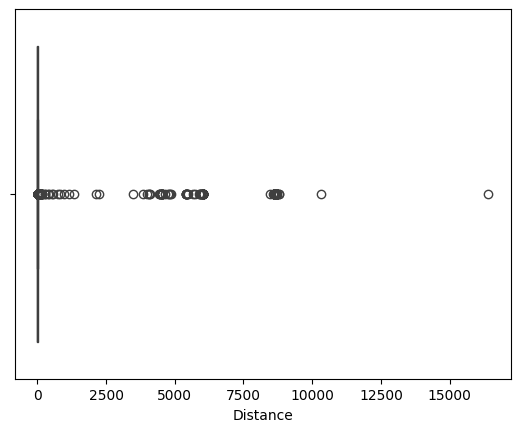

In [14]:
import seaborn as sns
sns.boxplot(data=df,x="Distance")

<Axes: xlabel='fare_amount'>

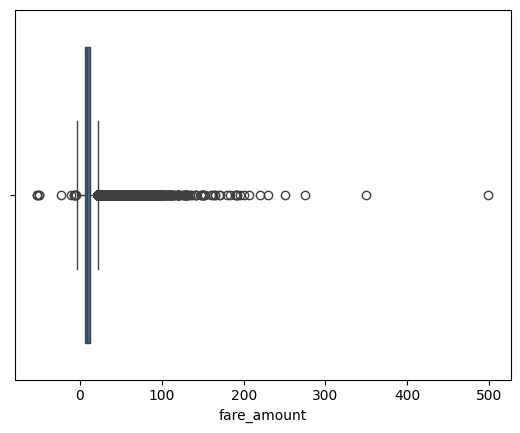

In [15]:
sns.boxplot(data=df,x="fare_amount")

In [16]:
#Remove any outliers using quartile method
def remove_outliers(df,column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3-Q1

    lower_bound = Q1-1.5*IQR
    upper_bound = Q3+1.5*IQR

    df = df[(df[column] >=lower_bound) & (df[column]<=upper_bound)]
    return df
df = remove_outliers(df,"fare_amount")
df = remove_outliers(df,"Distance")

<Axes: xlabel='Distance'>

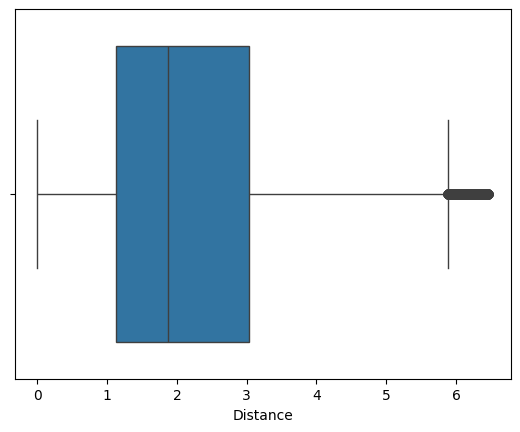

In [17]:
import seaborn as sns
sns.boxplot(data=df,x="Distance")


<Axes: xlabel='fare_amount'>

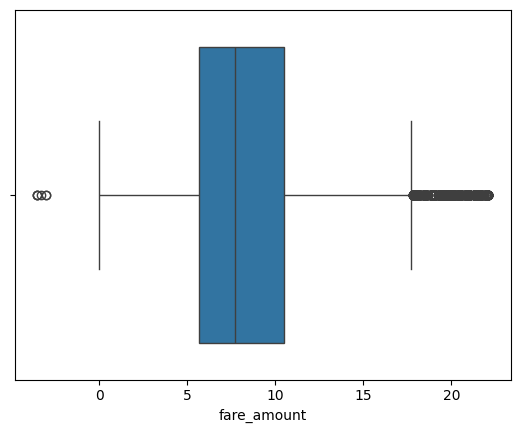

In [18]:
sns.boxplot(data=df,x="fare_amount")

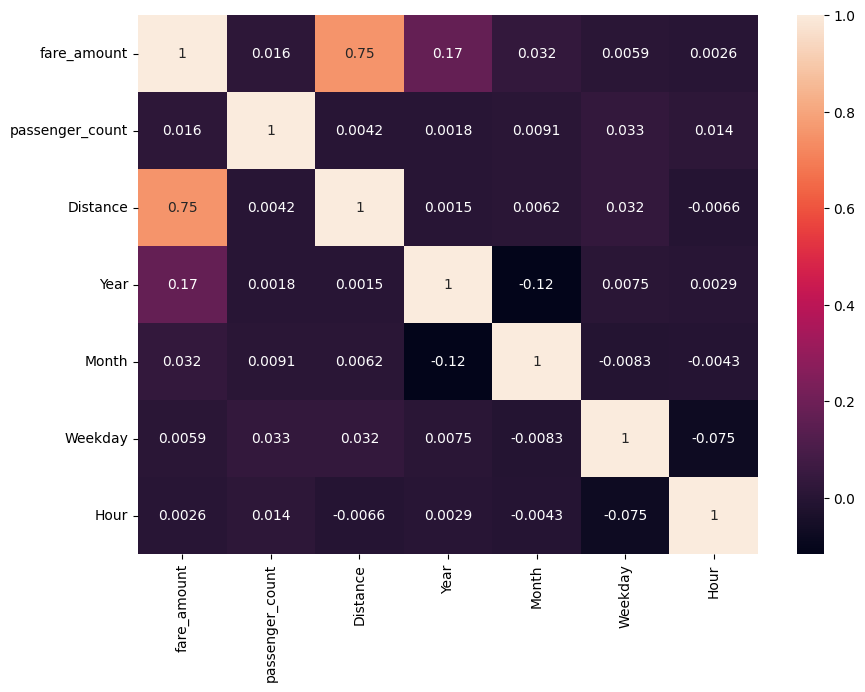

In [25]:
#Correlation analysis
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(),annot=True)
plt.show()

In [20]:
#Models training
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder

#Train -test split
X = df.drop(["fare_amount"],axis=1)
Y=df["fare_amount"]
X_train, X_test, Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=1)

#Standardize the columns

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [27]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train_scaled,Y_train)

#Prediction performed by model
ypred = model.predict(X_test_scaled)
ypred

array([ 5.87617412, 10.38495129,  6.32284214, ...,  7.70464411,
        3.75012971,  5.98486046])

In [28]:
from sklearn.metrics import r2_score, root_mean_squared_error,mean_absolute_error
print("R2 score:",r2_score(Y_test,y_pred))
print("RMSE: ", root_mean_squared_error(Y_test, y_pred))
print("MAE: ", mean_absolute_error(Y_test,y_pred))

NameError: name 'y_pred' is not defined

In [ ]:
#Random forest model
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train_scaled,Y_train)

y_pred = model.predict(X_test_scaled)
ypred

array([ 5.87617412, 10.38495129,  6.32284214, ...,  7.70464411,
        3.75012971,  5.98486046])

In [ ]:
print("R2 score:",r2_score(Y_test,y_pred))
print("RMSE: ", root_mean_squared_error(Y_test, y_pred))
print("MAE: ", mean_absolute_error(Y_test,y_pred))

R2 score: 0.6246417518863504
RMSE:  2.277404781355216
MAE:  1.6119689757501958
